# lmfit-global: How to prepare and run a simple `LmfitGlobal`

This notebook demonstrates how to use **lmfit-global** for
- multi-component models
- multi-dataset fitting
- shared parameters
- uncertainty evaluation

The example is intentionally simple and self-contained.

<p align="center">
  <img src="source/images/logo2.png" width="400">
</p

## 1. Imports

We import NumPy, matplotlib, and the core `LmfitGlobal` class.

In [1]:
try:
    from lmfit_global import LmfitGlobal
except (ImportError, ModuleNotFoundError):
    import os, sys
    ROOT = os.path.abspath("..") # parent folder of examples
    sys.path.insert(0, ROOT)
    from lmfit_global import LmfitGlobal

import numpy as np
import matplotlib.pyplot as plt


## 2. Define model functions

We define two simple components:
- A Gaussian peak
- An exponential background

These will be combined into a composite model.

### Built-in model functions

You can import a builtin function for example in the case of gaussian from

```python
from lmfit_global.utils import lineshapes
lineshape.gaussian
```

In [2]:
def gaussian(x, amplitude, center, sigma):
    return amplitude * np.exp(-(x - center)**2 / (2 * sigma**2))

def background(x, amplitude, decay):
    return amplitude * np.exp(-x / decay)

## 3. Generate synthetic multi-dataset data

We create two datasets sharing some parameters but with
independent amplitudes.

In [3]:
rng = np.random.default_rng(123)

x = np.linspace(0, 10, 200)

y1 = gaussian(x, amplitude=5.0, center=5.0, sigma=0.6) + background(x, 2.0, 6.0)
y2 = gaussian(x, amplitude=3.5, center=5.0, sigma=0.6) + background(x, 1.5, 6.0)

y1 += 0.15 * rng.normal(size=x.size)
y2 += 0.15 * rng.normal(size=x.size)

ylist = np.column_stack([y1, y2])
xy = np.column_stack([x, y1, y2])

## 4. Build lmfit-global input specification

The `items` dictionary defines:
- data
- model components
- how components are combined

There 3 different ways to build items, either way works

### (a) using manual method

In [4]:
items = {
    'data': {
        'xy': xy,
    },
    'functions': {
        'theory': [
            {
                'func_name': gaussian,
                'init_params': {
                    'amplitude':   {'value': 4.0, 'min': 0},
                    'center':      {'value': 4.5},
                    'sigma':       {'value': 0.8, 'min': 0},
                },
            },
            {
                'func_name': background,
                'init_params': {
                    'amplitude':  {'value': 1.0, 'min': 0},
                    'decay':      {'value': 5.0, 'min': 0},
                },
            },
        ],
        'theory_connectors': ['+'],  # or None or [] if single component
    }
}

### (b) using `utils.builders.build_items()` 

In [5]:
from lmfit_global.utils.builders import build_items

init_gauss = {
    'amplitude':   {'value': 4.0, 'min': 0},
    'center':      {'value': 4.5},
    'sigma':       {'value': 0.8, 'min': 0},
}
init_backg = {
    'amplitude':  {'value': 1.0, 'min': 0},
    'decay':      {'value': 5.0, 'min': 0},
}

items = build_items(
    xy=xy,
    functions=[
        {
            "func_name": gaussian,
            "init_params": init_gauss,
        },
        {
            "func_name": background,
            "init_params": init_backg,
        },
    ],
    connectors=["+"],  # or None or [] if single component
)

### (c) using `utils.builders.GlobalFitBuilder()` class

In [6]:
from lmfit_global.utils.builders import build_items, GlobalFitBuilder

init_gauss = {
    'amplitude':   {'value': 4.0, 'min': 0},
    'center':      {'value': 4.5},
    'sigma':       {'value': 0.8, 'min': 0},
}
init_backg = {
    'amplitude':  {'value': 1.0, 'min': 0},
    'decay':      {'value': 5.0, 'min': 0},
}

builder = (
    GlobalFitBuilder()
    .set_data(x, ylist)                      
    .add_model(gaussian,   init_gauss) 
    .add_model(background, init_backg)       
    .connect("+")                  # or None or [] if single component            
)

items = builder.build()

## 5. Create and configure the global fit

### first, pretty print initial parameters 

In [7]:
lg = LmfitGlobal(items, log_level='INFO')
lg.pretty_expr  # or lg.theory_expr

# lg.init_params.pretty_print()  # UNCOMMENT TO SEE INITIAL PARAMETERS

# Share center and width across datasets
lg.set_global('c0_center_0', 'c0_center_1')
lg.set_global('c0_sigma_0', 'c0_sigma_1')

# Share background decay
lg.set_global('c1_decay_0', 'c1_decay_1')

INFO: LmfitGlobal: Parsing inputs...
INFO: LmfitGlobal: Parsing input data...
INFO: LmfitGlobal: Detected 2 dataset(s) with N=200 points each
INFO: LmfitGlobal: XRANGE applied: [0.0, 10.0] → N=200 points per dataset
INFO: LmfitGlobal: Parsing input data COMPLETED...
INFO: LmfitGlobal: Parsing function models...
INFO: LmfitGlobal: 2 model component(s) detected — multi-component fit...
INFO: LmfitGlobal: Parsing function models COMPLETED...
INFO: LmfitGlobal: The model connectors used: [+]
INFO: LmfitGlobal: Parsing function(s) connectors COMPLETED...
INFO: LmfitGlobal: Building lmfit backend...
INFO: LmfitGlobal: Creating lmfit.Models for the models(s) function(s)...
INFO: LmfitGlobal: Building lmfit CompositeModel...
INFO: LmfitGlobal: CompositeModel built successfully...
INFO: LmfitGlobal: Initialized parameters...
INFO: LmfitGlobal: The model is to be constructed as...
INFO: LmfitGlobal: ############################################################################
INFO: LmfitGlobal: #

## 6. Run the fit

In [8]:
lg.fit(verbose=True)

INFO: LmfitGlobal: Fitting started (fit_method='leastsq') ...
INFO: LmfitGlobal: Parameters fit values:
INFO: LmfitGlobal: Name               Value      Min      Max   Stderr     Vary     Expr Brute_Step
INFO: LmfitGlobal: c0_amplitude_0      5.02        0      inf  0.04001     True     None     None
INFO: LmfitGlobal: c0_amplitude_1     3.505        0      inf  0.03787     True     None     None
INFO: LmfitGlobal: c0_center_0        5.003     -inf      inf 0.004561     True     None     None
INFO: LmfitGlobal: c0_center_1        5.003     -inf      inf 0.004561    False c0_center_0     None
INFO: LmfitGlobal: c0_sigma_0        0.5956        0      inf 0.005025     True     None     None
INFO: LmfitGlobal: c0_sigma_1        0.5956        0      inf 0.005025    False c0_sigma_0     None
INFO: LmfitGlobal: c1_amplitude_0     2.026        0      inf  0.02747     True     None     None
INFO: LmfitGlobal: c1_amplitude_1     1.501        0      inf  0.02489     True     None     None
INFO: L

## 7. Inspect results

In [9]:
lg.report() # or
# print(lg.fit_report(lg.result.params))

[[Model]]
    (Model(gaussian, prefix='c0_') + Model(background, prefix='c1_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 49
    # data points      = 400
    # variables        = 7
    chi-square         = 8.98220400
    reduced chi-square = 0.02285548
    Akaike info crit   = -1504.48770
    Bayesian info crit = -1476.54745
    R-squared          = 0.98621498
[[Variables]]
    c0_amplitude_0:  5.01959322 +/- 0.04000681 (0.80%) (init = 4)
    c0_center_0:     5.00348079 +/- 0.00456085 (0.09%) (init = 4.5)
    c0_sigma_0:      0.59555500 +/- 0.00502464 (0.84%) (init = 0.8)
    c1_amplitude_0:  2.02575762 +/- 0.02747047 (1.36%) (init = 1)
    c1_decay_0:      6.02069947 +/- 0.14541871 (2.42%) (init = 5)
    c0_amplitude_1:  3.50530903 +/- 0.03786611 (1.08%) (init = 4)
    c0_center_1:     5.00348079 +/- 0.00456085 (0.09%) == 'c0_center_0'
    c0_sigma_1:      0.59555500 +/- 0.00502464 (0.84%) == 'c0_sigma_0'
    c1_amplitude_1:  1.50064419 +/- 0.0248911

## 8. Plot data, fit, and residuals

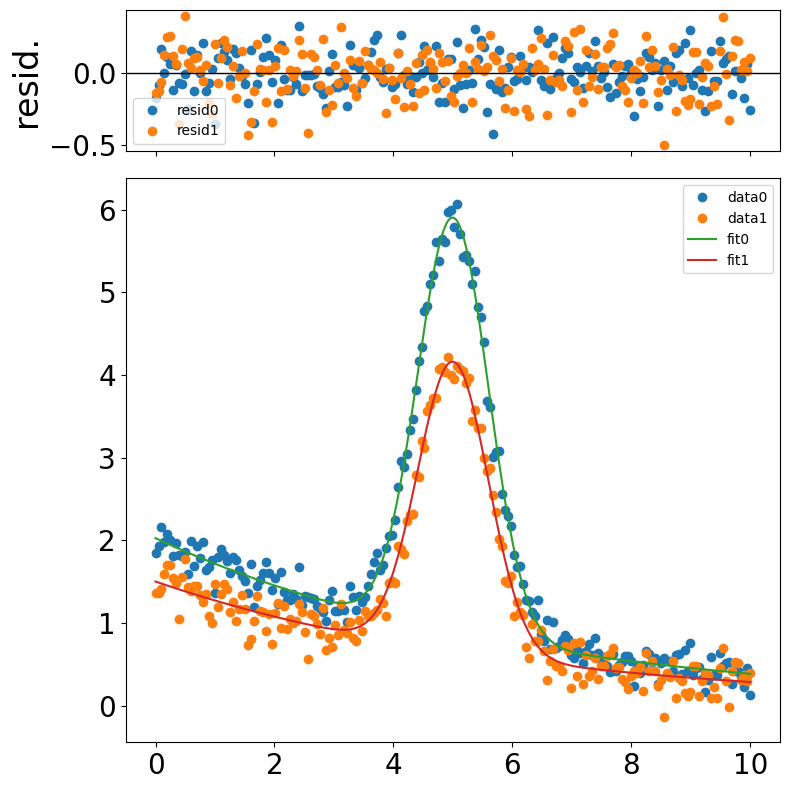

In [10]:
lg.plot(numpoints=600)
# UMCOMMENT BELOW FOR MORE FANCY PLOT
# pretty_kw={'width': 6, 'height':6, 'dpi':100} # width and height and dpi of figure, or None to use default settings
# lg.plot(numpoints=600, xlabel='x', ylabel='y', pretty_kw=pretty_kw)  # plot init parameters
plt.show()

## 9. Component-wise visualization

Each model component can be inspected individually.

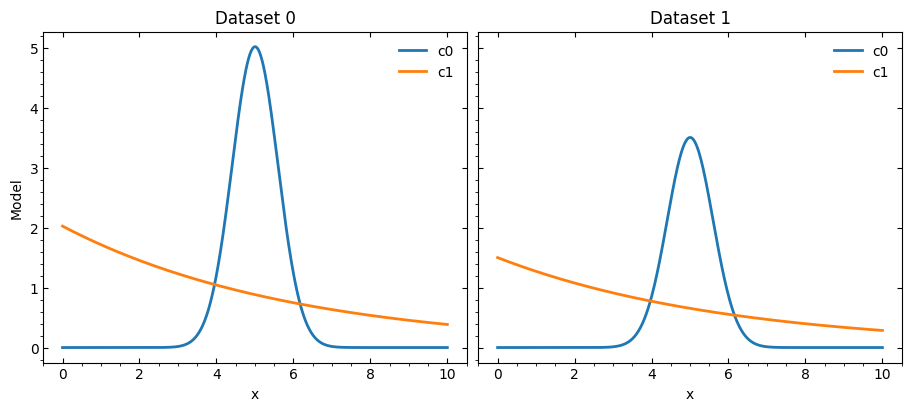

In [11]:
fitdata = lg.get_fitdata(numpoints=600)

components = fitdata.components
x = fitdata.x_model

datasets = sorted(components.keys())
nd = len(datasets)

fig, axes = plt.subplots(
    1, nd,
    figsize=(4.5 * nd, 4),
    sharey=True,
    constrained_layout=True
)

# Ensure axes is iterable for nd = 1
if nd == 1:
    axes = [axes]

for ax, dset in zip(axes, datasets):
    comps = components[dset]

    for name, vals in comps.items():
        ax.plot(
            x,
            vals["model"],
            lw=2,
            label=name,
        )

    ax.set_title(f"Dataset {dset}", fontsize=12)
    ax.set_xlabel("x")
    ax.minorticks_on()
    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(frameon=False)

axes[0].set_ylabel("Model")

plt.show()


## 10. Uncertainty bands

Compute 2σ (95.5 %) confidence intervals for the fitted model.

The allowed confidence interval are
- 1σ == 68.27% confidence level
- 2σ == 95.45% confidence level
- 3σ == 99.73% confidence level

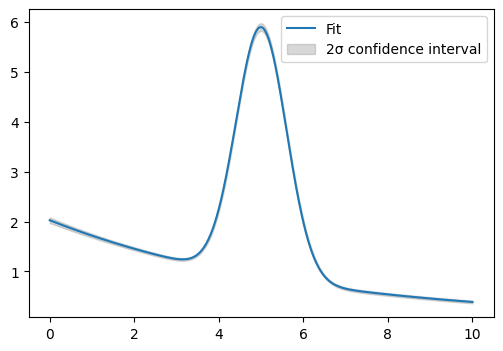

In [12]:
dely = lg.eval_uncertainty(
    x=fitdata.x_model,
    sigma=2,
)

dely_pred = lg.dely_predicted

plt.figure(figsize=(6, 4))
plt.plot(fitdata.x_model, fitdata.y_fit[:, 0], label='Fit')
plt.fill_between(
    fitdata.x_model,
    fitdata.y_fit[:, 0] - dely[:, 0],
    fitdata.y_fit[:, 0] + dely[:, 0],
    alpha=0.3,
    color="gray",   
    label='2σ confidence interval'
)

# plt.fill_between(
#     fitdata.x_model,
#     fitdata.y_fit[:, 0] - dely_pred[:, 0],
#     fitdata.y_fit[:, 0] + dely_pred[:, 0],
#     # alpha=0.3,
#     color="lightgray",   
#     label='2σ prediction level'
# )

plt.legend()
plt.show()

In [13]:
def _data_label(i: int, is_multidataset: bool) -> str | None:
    if is_multidataset:
        return f"data {i+1}"
    return "data" if i == 0 else None

def _fit_label(i: int, is_multidataset: bool, same_fit_color: bool) -> str | None:
    if not is_multidataset:
        return "fit" if i == 0 else None
    if same_fit_color:
        return "fit" if i == 0 else None
    return f"fit {i+1}"

COLORS = {
    "data": "#1F77B4",        # muted blue
    "fit": "#000000",         # black
    "conf": "#9E9E9E",        # medium gray
    "pred": "#D0D0D0",        # light gray
    "components": [
        "#D55E00",            # vermillion
        "#009E73",            # green
        "#CC79A7",            # purple
        "#E69F00",            # orange
    ],
}

PLOT_COMPONENTS = False
PLOT_TOTAL_UNCERTAINTY = True
PLOT_COMPONENT_UNCERTAINTY = True
PLOT_PREDICTION_UNCERTAINTY = False
SIGMA = 3

NEED_UNCERTAINTY = (
    PLOT_TOTAL_UNCERTAINTY
    or PLOT_COMPONENT_UNCERTAINTY
    or PLOT_PREDICTION_UNCERTAINTY
)

dely = None
dely_pred = None
dely_comps = None

fd = lg.get_fitdata(numpoints=1024) # int or None

if NEED_UNCERTAINTY:
    lg.eval_uncertainty(x=fd.x_model, sigma=SIGMA)
    dely = lg.dely
    dely_pred = getattr(lg, "dely_predicted", None)
    dely_comps = getattr(lg, "dely_comps", None)


dely_comps = (
    lg.dely_comps
    if (PLOT_COMPONENT_UNCERTAINTY and fd.is_multicomponent and hasattr(lg, "dely_comps"))
    else {}
)

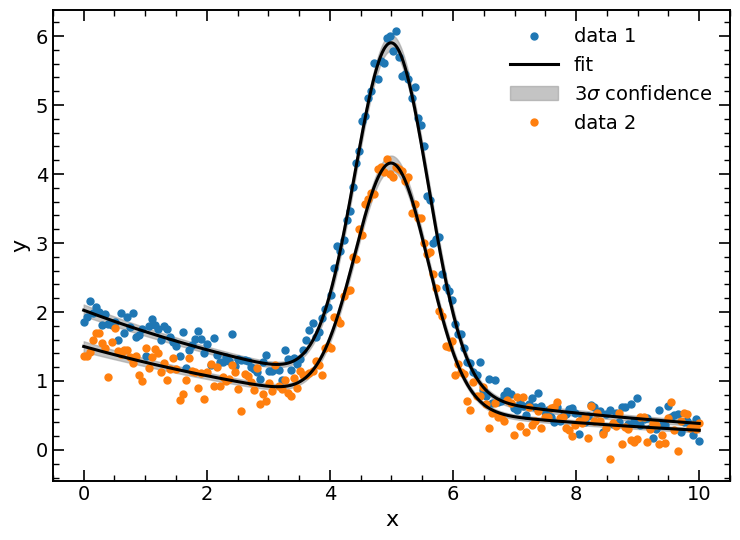

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

for i in range(fd.ny):

    # Data
    ax.plot(
        fd.x_data,
        fd.y_data[:, i],
        "o",
        ms=5,
        # color=COLORS["data"],
        zorder=4,
        label=_data_label(i, fd.is_multidataset),
    )

    # Total fit
    ax.plot(
        fd.x_model,
        fd.y_fit[:, i],
        "-",
        lw=2.2,
        color=COLORS["fit"],
        zorder=5,
        label=_fit_label(i, fd.is_multidataset, same_fit_color=True),
    )

    # Prediction interval (widest, behind)
    if PLOT_PREDICTION_UNCERTAINTY and dely_pred is not None:
        label = rf"{SIGMA}$\sigma$ prediction" if i == 0 else None
        ax.fill_between(
            fd.x_model,
            fd.y_fit[:, i] - dely_pred[:, i],
            fd.y_fit[:, i] + dely_pred[:, i],
            color=COLORS["pred"],
            alpha=0.45,
            zorder=1,
            label=label,
        )

    # Confidence interval (narrower, on top)
    if PLOT_TOTAL_UNCERTAINTY and dely is not None:
        label = rf"{SIGMA}$\sigma$ confidence" if i == 0 else None
        ax.fill_between(
            fd.x_model,
            fd.y_fit[:, i] - dely[:, i],
            fd.y_fit[:, i] + dely[:, i],
            color=COLORS["conf"],
            alpha=0.6,
            zorder=2,
            label=label,
        )

    # Components
    if PLOT_COMPONENTS and fd.is_multicomponent:

        comps = fd.components[i] if fd.is_multidataset else fd.components
        comp_names = fd.component_names

        for j, cname in enumerate(comp_names):
            ccol = COLORS["components"][j % len(COLORS["components"])]

            ax.plot(
                fd.x_model,
                comps[cname]["model"],
                "--",
                lw=1.8,
                # color=ccol,
                zorder=3,
                # label=cname if i == 0 else None,
            )

            # Component uncertainty
            if (
                PLOT_COMPONENT_UNCERTAINTY
                and dely_comps is not None
                and cname in dely_comps
            ):
                ax.fill_between(
                    fd.x_model,
                    comps[cname]["model"] - dely_comps[cname][:, i],
                    comps[cname]["model"] + dely_comps[cname][:, i],
                    color=ccol,
                    alpha=0.25,
                    zorder=2,
                )

# Styling
fontsize = 14

ax.set_xlabel("x", fontsize=fontsize + 2)
ax.set_ylabel("y", fontsize=fontsize + 2)

ax.minorticks_on()
ax.tick_params(
    direction="in",
    which="both",
    top=True,
    right=True,
    labelsize=fontsize,
)
ax.tick_params(which="major", length=8, width=1.2)
ax.tick_params(which="minor", length=4, width=1.0)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

# prop={
#     "size": fontsize-2,
#     "family": "sans-serif",
#     "weight": "normal",
# }
ax.legend(
    frameon=False,
    # prop=prop,
    fontsize=fontsize,
    handlelength=2.5,
    ncol=1,
)

plt.tight_layout()
plt.show()